In [1]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

print("--- 1. Przygotowanie Danych: TARGET_FAST_TRACK ---")

# 1. Wczytanie pliku
df_final = pd.read_parquet('flight_data_ml_ready.parquet')

# 2. Separacja zmiennej docelowej (y) - TYM RAZEM FAST TRACK
y = df_final['TARGET_FAST_TRACK']
target_cols = [col for col in df_final.columns if col.startswith('TARGET_')]
X = df_final.drop(columns=target_cols)

# 3. Oczyszczanie nazw kolumn
X = X.rename(columns=lambda x: re.sub('[^A-Za-z0-9_]+', '_', x))

# 4. Podział na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Dane gotowe! Fast Track kupiło: {sum(y)} osób z {len(y)} wszystkich wierszy.")
print(f"Zbiór treningowy: {X_train.shape[0]} wierszy, Zbiór testowy: {X_test.shape[0]} wierszy.")

--- 1. Przygotowanie Danych: TARGET_FAST_TRACK ---
Dane gotowe! Fast Track kupiło: 8019 osób z 527947 wszystkich wierszy.
Zbiór treningowy: 422357 wierszy, Zbiór testowy: 105590 wierszy.


In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

print("--- 2. Trenowanie Modelu: Random Forest (Fast Track) ---")

rf_model = RandomForestClassifier(
    n_estimators=100, max_depth=12, class_weight='balanced', random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
print("\n[RAPORT KLASYFIKACJI - Random Forest]:")
print(classification_report(y_test, y_pred_rf, target_names=['Brak Fast Track (0)', 'Kupi Fast Track (1)']))

--- 2. Trenowanie Modelu: Random Forest (Fast Track) ---

[RAPORT KLASYFIKACJI - Random Forest]:
                     precision    recall  f1-score   support

Brak Fast Track (0)       0.99      0.73      0.84    103986
Kupi Fast Track (1)       0.03      0.58      0.06      1604

           accuracy                           0.73    105590
          macro avg       0.51      0.65      0.45    105590
       weighted avg       0.98      0.73      0.83    105590



In [3]:
import xgboost as xgb
from sklearn.metrics import precision_recall_curve

print("--- 3. Trenowanie Modelu: XGBoost (Fast Track + Threshold Tuning) ---")

pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

xgb_model = xgb.XGBClassifier(
    n_estimators=150, max_depth=6, learning_rate=0.1,
    scale_pos_weight=pos_weight, random_state=42, n_jobs=-1, eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

# Szukanie progu dla Fast Track
y_probs_xgb = xgb_model.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs_xgb)

# Cel: Precyzja 30% (możesz obniżyć do 0.20, jeśli Fast Track jest bardzo rzadki)
target_precision = 0.30
try:
    optimal_idx = np.where(precisions >= target_precision)[0][0]
    optimal_threshold = thresholds[optimal_idx]
except IndexError:
    optimal_idx = np.argmax(precisions)
    optimal_threshold = thresholds[optimal_idx]

y_pred_xgb_optimal = (y_probs_xgb >= optimal_threshold).astype(int)

print(f"Ustalono nowy próg decyzyjny dla Fast Track: {optimal_threshold*100:.1f}%")
print("\n[RAPORT KLASYFIKACJI - XGBoost (Threshold Tuned)]:")
print(classification_report(y_test, y_pred_xgb_optimal, target_names=['Brak Fast Track (0)', 'Kupi Fast Track (1)']))

--- 3. Trenowanie Modelu: XGBoost (Fast Track + Threshold Tuning) ---
Ustalono nowy próg decyzyjny dla Fast Track: 87.4%

[RAPORT KLASYFIKACJI - XGBoost (Threshold Tuned)]:
                     precision    recall  f1-score   support

Brak Fast Track (0)       0.99      1.00      0.99    103986
Kupi Fast Track (1)       0.30      0.01      0.03      1604

           accuracy                           0.98    105590
          macro avg       0.64      0.51      0.51    105590
       weighted avg       0.97      0.98      0.98    105590



--- 6. Wyjaśnialność Modelu (SHAP) ---


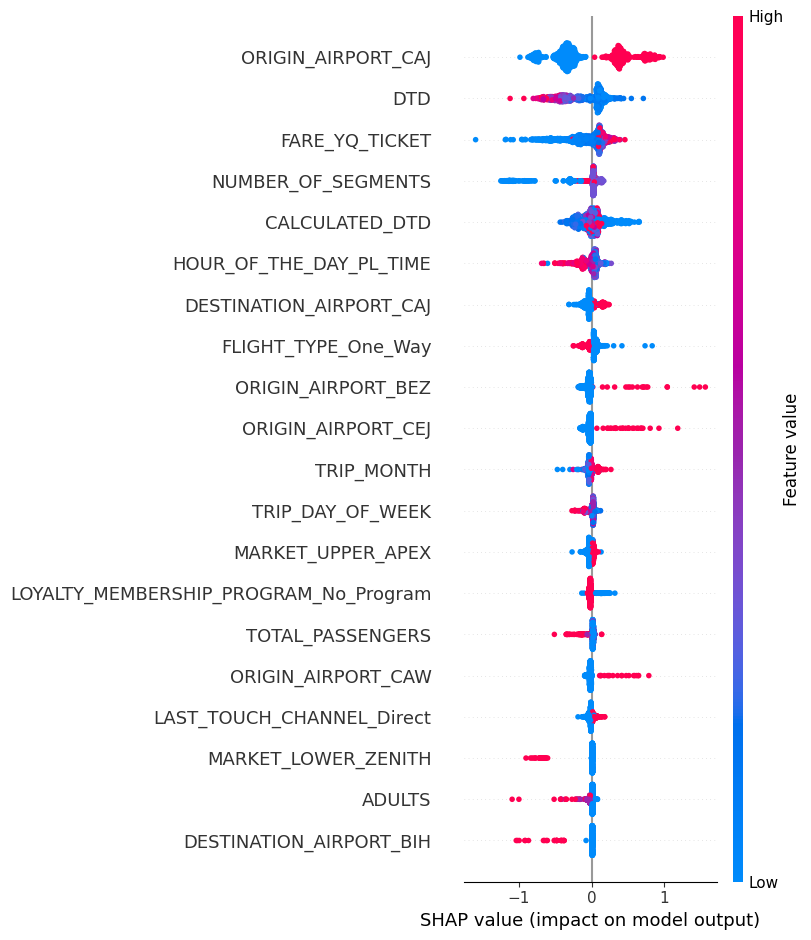

In [6]:
import shap

print("--- 6. Wyjaśnialność Modelu (SHAP) ---")
X_sample = X_test.head(1000)
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_sample)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample)

## new verison

1. Wczytywanie danych i podział (TARGET_FAST_TRACK)...
2. Uczenie WERSJI 2.0 dla FAST TRACK (Ekstremalne Lasso L1 i Płytsze Drzewa)...
3. Analiza Progu (Cel biznesowy: Precyzja ~12%)...

--- RAPORT MODELU FAST TRACK v2 (Próg: 78.4%) ---
                     precision    recall  f1-score   support

Brak Fast Track (0)       0.99      0.99      0.99    103986
Kupi Fast Track (1)       0.12      0.06      0.08      1604

           accuracy                           0.98    105590
          macro avg       0.55      0.53      0.54    105590
       weighted avg       0.97      0.98      0.98    105590


--- EFEKT EKSTREMALNEGO LASSO (L1=50) DLA FAST TRACK ---
Liczba kolumn na wejściu: 468
Kolumny użyte (przetrwały): 159
Kolumny wyzerowane (usunięte): 309

--- GENEROWANIE WYKRESÓW WYJAŚNIALNOŚCI (SHAP) ---


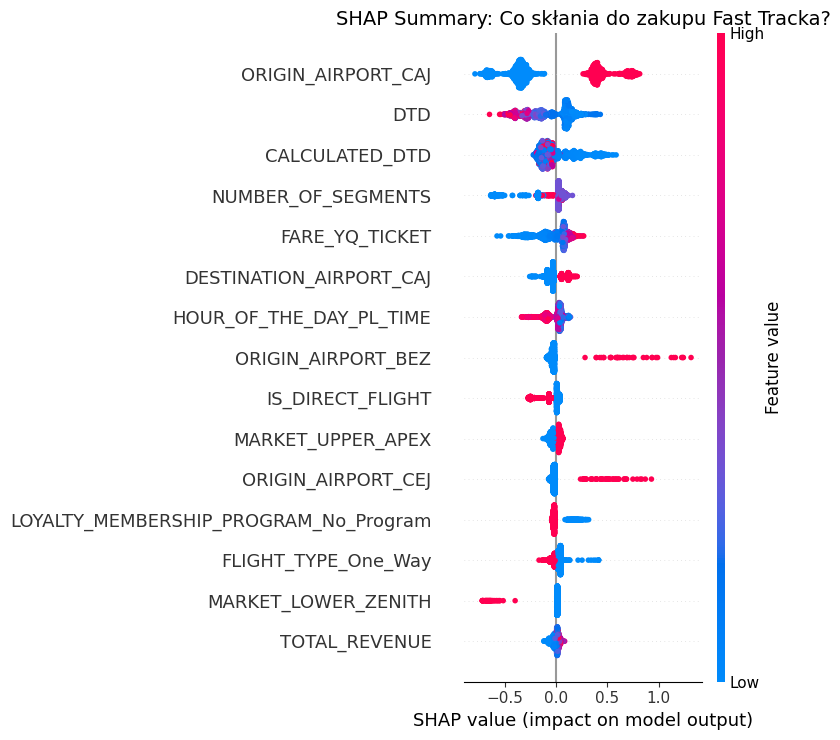

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, precision_recall_curve, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re
import shap

warnings.filterwarnings('ignore')

print("1. Wczytywanie danych i podział (TARGET_FAST_TRACK)...")
df_final = pd.read_parquet('flight_data_ml_ready.parquet')

# Zmieniamy cel na Fast Track
y = df_final['TARGET_FAST_TRACK']
target_cols = [col for col in df_final.columns if col.startswith('TARGET_')]
X = df_final.drop(columns=target_cols)

# Oczyszczanie nazw
X = X.rename(columns=lambda x: re.sub('[^A-Za-z0-9_]+', '_', x))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("2. Uczenie WERSJI 2.0 dla FAST TRACK (Ekstremalne Lasso L1 i Płytsze Drzewa)...")
# Wyrównanie klas (bardzo ważne dla 1.5% kupujących)
pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

xgb_model_ft_v2 = xgb.XGBClassifier(
    n_estimators=300,          # Więcej małych kroków
    learning_rate=0.03,        
    max_depth=4,               # Płytsze drzewa, prosta logika
    colsample_bytree=0.8,      # Losowe ukrywanie cech
    scale_pos_weight=pos_weight, 
    reg_alpha=50,              # POTĘŻNE LASSO (L1) - tnie niepotrzebne kolumny jak maczeta
    reg_lambda=10,             # Ridge (L2) - stabilizuje model
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

xgb_model_ft_v2.fit(X_train, y_train)

print("3. Analiza Progu (Cel biznesowy: Precyzja ~12%)...")
y_probs_ft_v2 = xgb_model_ft_v2.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs_ft_v2)

# Celujemy w 12% precyzji, by uzyskać przyzwoity zasięg (Recall)
target_precision = 0.12
try:
    optimal_idx = np.where(precisions >= target_precision)[0][0]
    optimal_threshold = thresholds[optimal_idx]
except IndexError:
    optimal_idx = np.argmax(precisions)
    optimal_threshold = thresholds[optimal_idx]

y_pred_ft_v2 = (y_probs_ft_v2 >= optimal_threshold).astype(int)

print(f"\n--- RAPORT MODELU FAST TRACK v2 (Próg: {optimal_threshold*100:.1f}%) ---")
print(classification_report(y_test, y_pred_ft_v2, target_names=['Brak Fast Track (0)', 'Kupi Fast Track (1)']))

# --- EFEKT EKSTREMALNEJ REGULARYZACJI ---
print("\n--- EFEKT EKSTREMALNEGO LASSO (L1=50) DLA FAST TRACK ---")
used_features = xgb_model_ft_v2.get_booster().get_fscore()
num_used = len(used_features)
num_total = X.shape[1]
print(f"Liczba kolumn na wejściu: {num_total}")
print(f"Kolumny użyte (przetrwały): {num_used}")
print(f"Kolumny wyzerowane (usunięte): {num_total - num_used}")

# --- MAGIA SHAP: CO NAPĘDZA FAST TRACK? ---
print("\n--- GENEROWANIE WYKRESÓW WYJAŚNIALNOŚCI (SHAP) ---")
X_sample = X_test.head(2000)

explainer = shap.TreeExplainer(xgb_model_ft_v2)
shap_values = explainer.shap_values(X_sample)

plt.figure(figsize=(12, 8))
plt.title('SHAP Summary: Co skłania do zakupu Fast Tracka?', fontsize=14)
shap.summary_plot(shap_values, X_sample, max_display=15, show=False)
plt.tight_layout()
plt.show()